In [1]:
!nvidia-smi

Sun Sep 13 12:00:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

!pip install -q --upgrade datasets transformers accelerate huggingface_hub scikit-learn wandb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opent

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import subprocess
import wandb

from PIL import Image
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from torchvision import transforms

from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from google.colab import userdata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## W&B setup

In [4]:

wandb_key = userdata.get("WANDB_API_KEY")
if wandb_key:
    wandb.login(key=wandb_key)
else:
    print("WANDB_API_KEY was not found in Colab Secrets.")


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: epiuradai (epiuradai-makerere-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:

hf_token = userdata.get("HF_MARC")
if hf_token:
    from huggingface_hub import login
    login(token=hf_token)

repo_model_name = "Marc-HealthAI/FP_Classifcation-V1"


config = {
    "learning_rate": 1e-3,
    "epochs": 50,
    "train_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "eval_batch_size": 16,
    "image_resolution": 128,
    "architecture": "CNN-Pytorch",
    "dataset": "Marc-HealthAI/fetal-planes-classification-dataset-main",
    "early_stopping_patience": 5,
    "early_stopping_threshold": 0.001,
}

run = wandb.init(
    project="Marc-HealthAI FP Classification",
    config=config, name=repo_model_name
)


## Load the dataset directly from Hugging Face

In [8]:
HF_dataset = config["dataset"]

dataset = load_dataset(HF_dataset)

print(dataset)
for split_name, split_ds in dataset.items():
    print(f"{split_name}: {len(split_ds)} rows")
    print("Columns:", split_ds.column_names)
    print()


README.md:   0%|          | 0.00/2.67k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  614MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  699MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7720 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2475 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2205 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Split', 'image'],
        num_rows: 7720
    })
    validation: Dataset({
        features: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Split', 'image'],
        num_rows: 2475
    })
    test: Dataset({
        features: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Split', 'image'],
        num_rows: 2205
    })
})
train: 7720 rows
Columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Split', 'image']

validation: 2475 rows
Columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Split', 'image']

test: 2205 rows
Columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Split', 'image']



In [9]:

train_dataset = dataset["train"]
test_dataset = dataset["test"]
val_dataset = dataset["validation"]


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

train_patients = set(train_dataset["Patient_num"])
val_patients = set(val_dataset["Patient_num"])
test_patients = set(test_dataset["Patient_num"])

print("Patient overlap train/val:", len(train_patients & val_patients))
print("Patient overlap train/test:", len(train_patients & test_patients))
print("Patient overlap val/test:", len(val_patients & test_patients))


Train: 7720
Validation: 2475
Test: 2205
Patient overlap train/val: 0
Patient overlap train/test: 0
Patient overlap val/test: 0


In [10]:
class_names = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other",
]

label_map = {name: idx for idx, name in enumerate(class_names)}

print("Train class distribution:")
print(pd.Series(train_dataset["Plane"]).value_counts())


Train class distribution:
Other              2548
Fetal brain        1947
Fetal thorax       1072
Maternal cervix    1045
Fetal femur         657
Fetal abdomen       451
Name: count, dtype: int64


## Image transforms and PyTorch dataset wrapper

In [11]:
resolution = config["image_resolution"]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((resolution, resolution)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


class FetalPlanesTorchDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]

        image = row["image"]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.asarray(image))

        label_name = str(row["Plane"]).strip()
        if label_name not in label_map:
            raise ValueError(f"Unknown Plane label: {label_name!r}")

        image = image.convert("L")

        if self.transform:
            image = self.transform(image)

        return {
            "pixel_values": image,
            "labels": label_map[label_name],
        }


train_torch_dataset = FetalPlanesTorchDataset(train_dataset, train_transform)
val_torch_dataset = FetalPlanesTorchDataset(val_dataset, eval_transform)
test_torch_dataset = FetalPlanesTorchDataset(test_dataset, eval_transform)

print(train_torch_dataset[0]["pixel_values"].shape)
print(train_torch_dataset[0]["labels"])


torch.Size([1, 128, 128])
5


## Class-weighted loss

In [12]:
train_labels = np.asarray([
    label_map[str(label).strip()]
    for label in train_dataset["Plane"]
])

calculated_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_labels,
)

class_weights = torch.tensor(
    calculated_weights,
    dtype=torch.float32,
)

print("Class weights:")
for name, weight in zip(class_names, calculated_weights):
    print(f"{name:20s}: {weight:.4f}")


Class weights:
Fetal abdomen       : 2.8529
Fetal brain         : 0.6608
Fetal femur         : 1.9584
Fetal thorax        : 1.2002
Maternal cervix     : 1.2313
Other               : 0.5050


## CNN model

In [13]:
class FetalPlaneCNN(nn.Module):
    def __init__(self, num_classes=6, class_weights=None):
        super().__init__()

        self.features = nn.Sequential(
            # Input: (1, 128, 128)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # (32, 64, 64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # (64, 32, 32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights)
        else:
            self.class_weights = None

    def forward(self, pixel_values=None, labels=None):
        x = self.features(pixel_values)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fn(logits, labels)

        return {
            "loss": loss,
            "logits": logits,
        }


model = FetalPlaneCNN(
    num_classes=len(class_names),
    class_weights=class_weights,
)

print(model)


FetalPlaneCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout2d(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Lin

## Metrics

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }


In [15]:
training_args = TrainingArguments(
    output_dir=repo_model_name,
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",

    # Adapted from the original notebook's CNN training setup.
    learning_rate=config["learning_rate"],
    lr_scheduler_type="cosine",

    dataloader_num_workers=2,
    per_device_train_batch_size=config["train_batch_size"],
    gradient_accumulation_steps=config["gradient_accumulation_steps"],
    per_device_eval_batch_size=config["eval_batch_size"],

    num_train_epochs=config["epochs"],


    logging_steps=10,

    report_to="wandb",

    load_best_model_at_end=True,
    metric_for_best_model="recall_macro",
    greater_is_better=True,

    save_total_limit=2,


    fp16=torch.cuda.is_available(),
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_torch_dataset,
    eval_dataset=val_torch_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=config["early_stopping_patience"],
            early_stopping_threshold=config["early_stopping_threshold"],
        )
    ],
)

print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start

## Train

In [16]:
train_result = trainer.train()

print("Training complete.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.086932,0.765695,0.679192,0.683662,0.705303,0.671014
2,0.980116,0.745750,0.750707,0.736981,0.700437,0.705462
3,0.922654,0.654533,0.714343,0.707486,0.783119,0.699889
4,0.703613,0.598894,0.773333,0.747556,0.805793,0.759307
5,0.672895,0.517485,0.783030,0.761723,0.840852,0.775330
6,0.819983,0.492891,0.786263,0.754066,0.839827,0.773515
7,0.774991,0.456951,0.815354,0.783012,0.847559,0.803767
8,0.801501,0.449401,0.838384,0.809014,0.849348,0.824304
9,0.632600,0.492792,0.826263,0.806554,0.815145,0.803925
10,0.767514,0.439674,0.834747,0.802112,0.859088,0.817454


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.086932,0.765695,0.679192,0.683662,0.705303,0.671014
2,0.980116,0.745750,0.750707,0.736981,0.700437,0.705462
3,0.922654,0.654533,0.714343,0.707486,0.783119,0.699889
4,0.703613,0.598894,0.773333,0.747556,0.805793,0.759307
5,0.672895,0.517485,0.783030,0.761723,0.840852,0.775330
6,0.819983,0.492891,0.786263,0.754066,0.839827,0.773515
7,0.774991,0.456951,0.815354,0.783012,0.847559,0.803767
8,0.801501,0.449401,0.838384,0.809014,0.849348,0.824304
9,0.632600,0.492792,0.826263,0.806554,0.815145,0.803925
10,0.767514,0.439674,0.834747,0.802112,0.859088,0.817454


Training complete.
Best checkpoint: Marc-HealthAI/FP_Classifcation-V1/checkpoint-16422
Best metric: 0.9098080870277396


Pushing to Github

## Final validation evaluation

In [17]:
val_metrics = trainer.evaluate(
    eval_dataset=val_torch_dataset,
)

print("Best-model validation metrics:")
for key, value in val_metrics.items():
    if isinstance(value, (float, int)):
        print(f"{key}: {value:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.276571,0.293984,39,0.902626,0.874221,0.909808,0.889517


Best-model validation metrics:
eval_loss: 0.2940
eval_accuracy: 0.9026
eval_precision_macro: 0.8742
eval_recall_macro: 0.9098
eval_f1_macro: 0.8895


## Final test evaluation

In [18]:
test_output = trainer.predict(test_torch_dataset)

test_logits = test_output.predictions
test_labels = test_output.label_ids
test_predictions = np.argmax(test_logits, axis=-1)

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

test_accuracy = accuracy_score(test_labels, test_predictions)
test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0,
)

precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0,
)
test_precision = precision_macro
test_recall = recall_macro

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test F1 Macro : {test_f1:.4f}")
print(f"Test Precision Macro : {test_precision:.4f}")
print(f"Test Recall Macro : {test_recall:.4f}")

report_str = classification_report(
    test_labels,
    test_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0,
)

print("\nClassification Report:")
print(report_str)

# Save classification report to a file
report_file_path = os.path.join(repo_model_name, "classification_report.txt")
with open(report_file_path, "w") as f:
    f.write(report_str)


FINAL TEST RESULTS
Test Accuracy : 0.9215
Test F1 Macro : 0.9014
Test Precision Macro : 0.8899
Test Recall Macro : 0.9145

Classification Report:
                 precision    recall  f1-score   support

  Fetal abdomen     0.7842    0.8583    0.8195       127
    Fetal brain     0.9882    0.9862    0.9872       509
    Fetal femur     0.7967    0.8788    0.8357       165
   Fetal thorax     0.8467    0.8889    0.8673       261
Maternal cervix     0.9880    0.9802    0.9841       253
          Other     0.9354    0.8944    0.9144       890

       accuracy                         0.9215      2205
      macro avg     0.8899    0.9145    0.9014      2205
   weighted avg     0.9240    0.9215    0.9223      2205



In [19]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

print("Confusion Matrix:")
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)
print(cm_df)

# Save confusion matrix DataFrame to a CSV file
cm_csv_file_path = os.path.join(repo_model_name, "confusion_matrix.csv")
cm_df.to_csv(cm_csv_file_path, index=True)


Confusion Matrix:
                 Fetal abdomen  Fetal brain  Fetal femur  Fetal thorax  \
Fetal abdomen              109            1            0             7   
Fetal brain                  0          502            3             1   
Fetal femur                  0            1          145             1   
Fetal thorax                 7            0            0           232   
Maternal cervix              1            0            0             0   
Other                       22            4           34            33   

                 Maternal cervix  Other  
Fetal abdomen                  1      9  
Fetal brain                    0      3  
Fetal femur                    1     17  
Fetal thorax                   0     22  
Maternal cervix              248      4  
Other                          1    796  


In [22]:

from transformers import PretrainedConfig


custom_config = PretrainedConfig(
    _name_or_path=repo_model_name,
    num_labels=len(class_names)
)
model.config = custom_config




Visualization

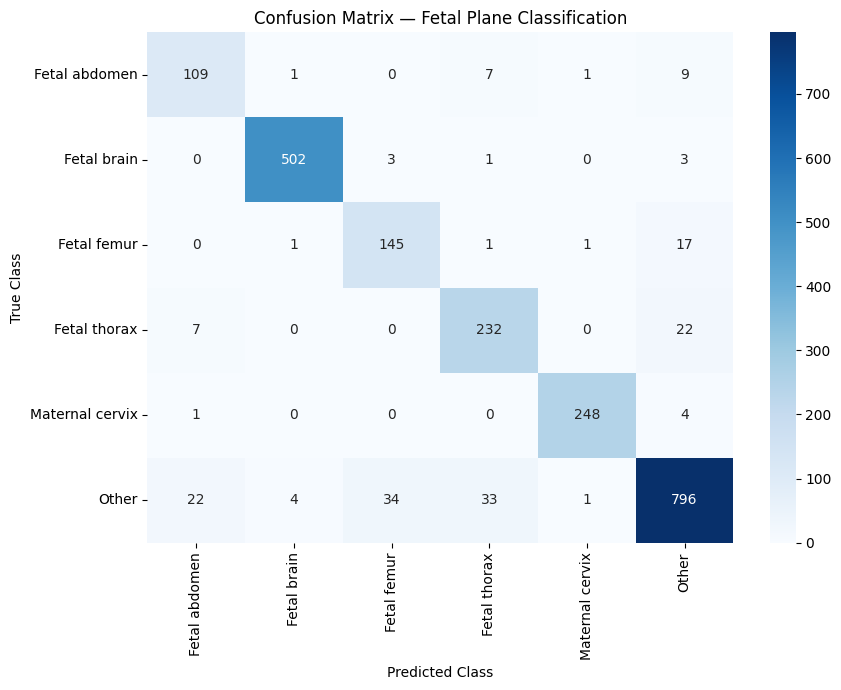

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix — Fetal Plane Classification")

plt.tight_layout()

# Save the confusion matrix
cm_plot_file_path = os.path.join(repo_model_name, "confusion_matrix.png")
plt.savefig(cm_plot_file_path)

plt.show()


In [24]:
# Get training history
history = pd.DataFrame(trainer.state.log_history)

display(history)




,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,14.636790,140.261322,0.001000,0.020725,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.822578,95.855377,0.001000,0.041451,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6.465566,81.523651,0.001000,0.062176,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.234132,28.385473,0.001000,0.082902,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.685892,35.809395,0.001000,0.103627,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,0.238252,1.469830,0.000115,38.965803,18820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1920,0.276571,7.737907,0.000115,38.986528,18830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1921,NaN,NaN,NaN,39.000000,18837,0.294422,0.902222,0.879328,0.900566,0.888965,15.6253,158.397,9.920,NaN,NaN,NaN,NaN,NaN
1922,NaN,NaN,NaN,39.000000,18837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3068.0933,125.811,7.871,0.0,0.553965


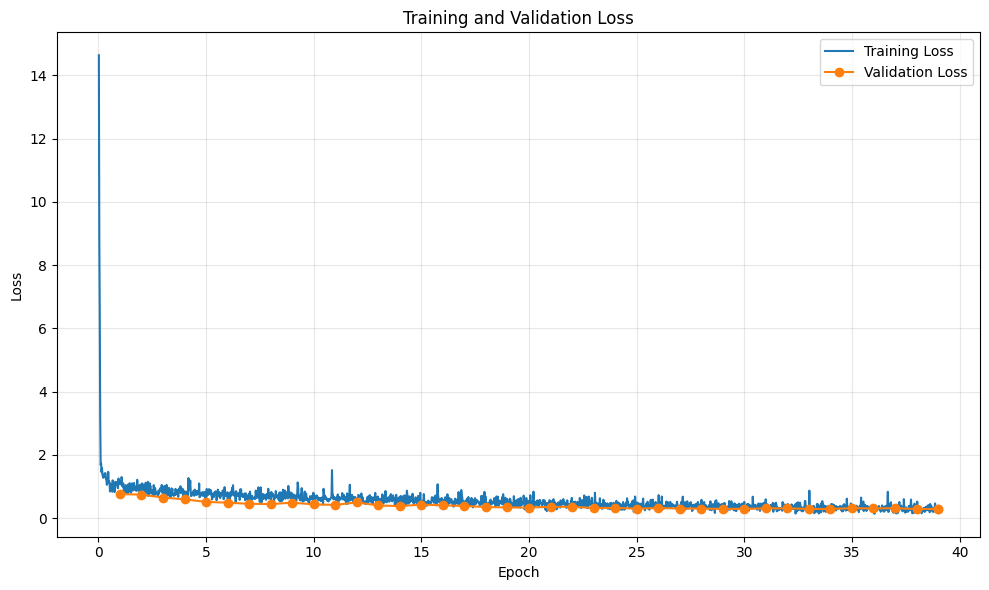

In [25]:
plt.figure(figsize=(10, 6))

# Training loss
train_loss = history.dropna(subset=["loss"])

plt.plot(
    train_loss["epoch"],
    train_loss["loss"],
    label="Training Loss"
)

# Validation loss
eval_loss = history.dropna(subset=["eval_loss"])

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

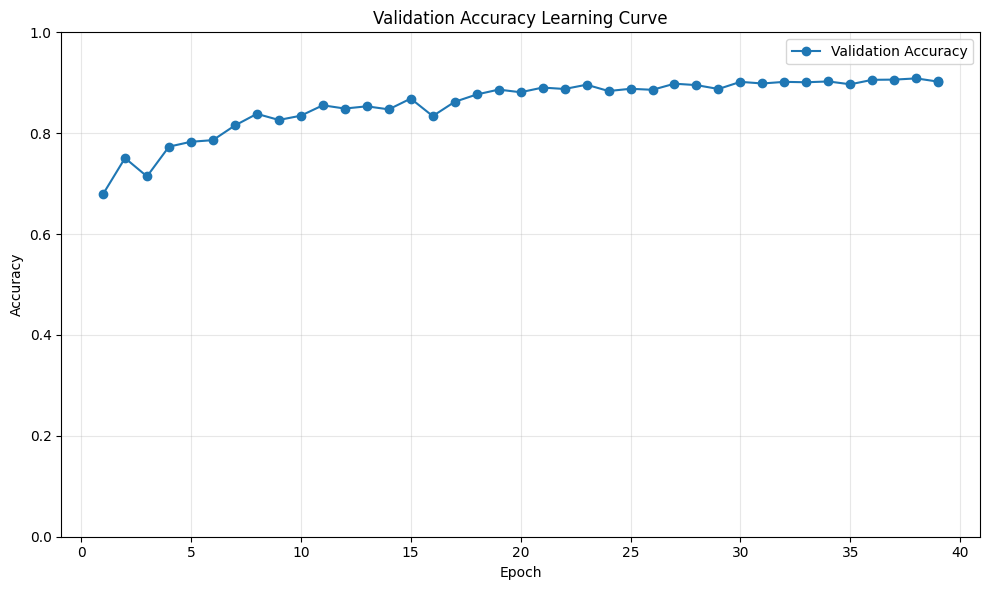

In [26]:
eval_history = history.dropna(subset=["eval_accuracy"])

plt.figure(figsize=(10, 6))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Learning Curve")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Precision, Recall, F1

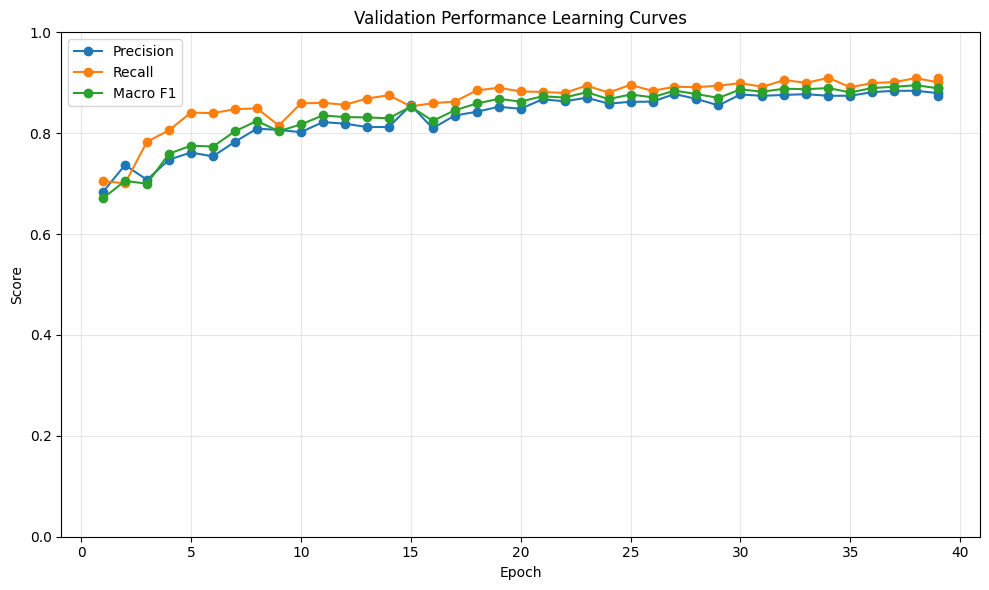

In [27]:
eval_history = history.dropna(
    subset=[
        "eval_precision_macro",
        "eval_recall_macro",
        "eval_f1_macro"
    ]
)

plt.figure(figsize=(10, 6))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_precision_macro"],
    marker="o",
    label="Precision"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_recall_macro"],
    marker="o",
    label="Recall"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_f1_macro"],
    marker="o",
    label="Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance Learning Curves")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Log final test metrics to W&B
wandb.log({
    "test_accuracy": test_accuracy,
    "test_f1_macro": test_f1,
    "test_precision_macro": test_precision,
    "test_recall_macro": test_recall,
    "confusion_matrix": wandb.plot.confusion_matrix(
        preds=test_predictions,
        y_true=test_labels,
        class_names=class_names
    ),
    "classification_report": wandb.Table(
        dataframe=pd.DataFrame(classification_report(
            test_labels,
            test_predictions,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )).transpose()
    )
})

wandb.finish()


eval/accuracy,▁▃▂▄▄▄▅▆▅▆▆▆▆▆▇▆▇▇▇▇▇▇█▇▇▇██▇███████████
eval/f1_macro,▁▂▂▄▄▄▅▆▅▆▆▆▆▆▇▆▆▇▇▇▇▇█▇▇▇█▇▇███████████
eval/loss,██▆▆▄▄▃▃▄▃▃▄▃▂▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/precision_macro,▁▃▂▃▄▃▄▅▅▅▆▆▅▅▇▅▆▇▇▇▇▇█▇▇▇█▇▇███████████
eval/recall_macro,▁▁▄▅▆▆▆▆▅▆▆▆▇▇▆▆▆▇▇▇▇▇▇▇█▇▇▇▇█▇███▇█████
eval/runtime,▅▁▁▁▁▁▁█▁▃▁▁▁▂▁▂▁▂▁▁▂▁▁▁▂▁▁▁▁▁▁▂▁▁▂▁▁▂▁▁
eval/samples_per_second,▃██████▁█▅▇██▇█▇▇▇▇▇▆▇▇█▇████▇█▆██▆▇█▇██
eval/steps_per_second,▃██████▁█▅▇██▇█▇▇▇▇▇▆▇▇█▇████▇█▆██▆▇█▇██
test/accuracy,▁
test/f1_macro,▁
+15,...


Push to GitHub

In [43]:
import re

branch = "colab"


trainer.save_model(repo_model_name)
generated_readme_path = os.path.join(repo_model_name, "README.md")

eval_summary_content = ""
training_results_content = ""

if os.path.exists(generated_readme_path):
    with open(generated_readme_path, "r", encoding="utf-8") as f:
        gen_text = f.read()

    # Extract top evaluation summary bullet points
    eval_match = re.search(r"(It achieves the following results on the evaluation set:\s*\n)([\s\S]*?)(?=\n## Model description)", gen_text)
    if eval_match:
        eval_summary_content = eval_match.group(2).strip()

    # Extract training hyperparameters & results table
    train_match = re.search(r"(### Training hyperparameters[\s\S]*?)(?=\n### Framework versions)", gen_text)
    if train_match:
        training_results_content = train_match.group(1).strip()

# Cleanup checkpoint folders locally
for item in os.listdir(repo_model_name):
    if item.startswith("checkpoint-"):
        shutil.rmtree(os.path.join(repo_model_name, item))

# Create .gitignore and requirements.txt
with open(os.path.join(repo_model_name, ".gitignore"), "w") as f:
    f.write("checkpoint-*/\nruns/\n")

!pip freeze > {os.path.join(repo_model_name, "requirements.txt")}

In [44]:
github_token = userdata.get("GH_TOKEN")
github_repo_url = userdata.get("REPO_URL")
git_email = userdata.get("Email")
git_name = userdata.get("NAME")

auth_repo_url = github_repo_url.replace("https://", f"https://{github_token}@")

# Pull latest README from GitHub to preserve your custom sections
push_script = f"""
cd {repo_model_name}
if [ ! -d ".git" ]; then
    git init
    git remote add origin {auth_repo_url}
fi
git remote set-url origin {auth_repo_url}
git config user.email "{git_email}"
git config user.name "{git_name}"
git checkout -B {branch}

# Fetch the existing README so we keep your descriptions
git fetch origin {branch} 2>/dev/null || true
git checkout origin/{branch} -- README.md 2>/dev/null || true
rm -rf checkpoint-*
"""
subprocess.run(push_script, shell=True, capture_output=True)

# 6. Inject the fresh data into your custom README
target_readme_path = os.path.join(repo_model_name, "README.md")
if os.path.exists(target_readme_path):
    with open(target_readme_path, "r", encoding="utf-8") as f:
        readme_data = f.read()

    # Replace Evaluation Summary
    if eval_summary_content and "<!-- START_EVAL_SUMMARY -->" in readme_data:
        readme_data = re.sub(
            r"<!-- START_EVAL_SUMMARY -->[\s\S]*?<!-- END_EVAL_SUMMARY -->",
            f"<!-- START_EVAL_SUMMARY -->\n{eval_summary_content}\n<!-- END_EVAL_SUMMARY -->",
            readme_data
        )

    # Replace Training Procedure & Results Table
    if training_results_content and "<!-- START_TRAINING_RESULTS -->" in readme_data:
        readme_data = re.sub(
            r"<!-- START_TRAINING_RESULTS -->[\s\S]*?<!-- END_TRAINING_RESULTS -->",
            f"<!-- START_TRAINING_RESULTS -->\n{training_results_content}\n<!-- END_TRAINING_RESULTS -->",
            readme_data
        )

    with open(target_readme_path, "w", encoding="utf-8") as f:
        f.write(readme_data)

# Final push to GitHub
final_push_script = f"""
cd {repo_model_name}
git rm -rf checkpoint-* 2>/dev/null || true
git add .
git commit -m "Auto-update dynamic training results and model files on {branch}" || echo "No changes to commit"
git push -u origin {branch} --force
"""

result = subprocess.run(final_push_script, shell=True, capture_output=True, text=True)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)

if result.returncode == 0:
    print(f"Successfully updated README results and pushed to branch '{branch}'!")
else:
    print("Check logs above for details.")

STDOUT:
 On branch colab
Your branch is up to date with 'origin/colab'.

nothing to commit, working tree clean
No changes to commit
branch 'colab' set up to track 'origin/colab'.

STDERR:
 Everything up-to-date

Successfully updated README results and pushed to branch 'colab'!
